## 🏠 House Price Prediction Project

### 📥 Part B : Data Acquisition

### 📚 Import Libraries

In [44]:
import pandas as pd 
from ydata_profiling import ProfileReport
import numpy as np  
import matplotlib.pyplot as plt
import seaborn as sns

### 📄 Load CSV File Using Pandas

In [45]:
df = pd.read_csv("house_price_prediction.csv")
df

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY
...,...,...,...,...,...,...,...,...,...,...
20635,-121.09,39.48,25.0,1665.0,374.0,845.0,330.0,1.5603,78100.0,INLAND
20636,-121.21,39.49,18.0,697.0,150.0,356.0,114.0,2.5568,77100.0,INLAND
20637,-121.22,39.43,17.0,2254.0,485.0,1007.0,433.0,1.7000,92300.0,INLAND
20638,-121.32,39.43,18.0,1860.0,409.0,741.0,349.0,1.8672,84700.0,INLAND


### 📑 Parse a JSON File

In [46]:
df_json = pd.read_json("house_price_prediction.json")
df_json

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41,880,129.0,322,126,8.3252,452600,NEAR BAY
1,-122.22,37.86,21,7099,1106.0,2401,1138,8.3014,358500,NEAR BAY
2,-122.24,37.85,52,1467,190.0,496,177,7.2574,352100,NEAR BAY
3,-122.25,37.85,52,1274,235.0,558,219,5.6431,341300,NEAR BAY
4,-122.25,37.85,52,1627,280.0,565,259,3.8462,342200,NEAR BAY
...,...,...,...,...,...,...,...,...,...,...
20635,-121.09,39.48,25,1665,374.0,845,330,1.5603,78100,INLAND
20636,-121.21,39.49,18,697,150.0,356,114,2.5568,77100,INLAND
20637,-121.22,39.43,17,2254,485.0,1007,433,1.7000,92300,INLAND
20638,-121.32,39.43,18,1860,409.0,741,349,1.8672,84700,INLAND


### 🗄️ Connect to SQL Database and Fetch Records

In [83]:
import sqlite3
conn = sqlite3.connect("house_price_prediction.db")
df = pd.read_sql_query("SELECT * FROM house_price_prediction",conn)
print(df.head())
print(df.shape)
conn.close()

   longitude  latitude  housing_median_age  total_rooms  total_bedrooms  \
0    -122.23     37.88                41.0        880.0           129.0   
1    -122.22     37.86                21.0       7099.0          1106.0   
2    -122.24     37.85                52.0       1467.0           190.0   
3    -122.25     37.85                52.0       1274.0           235.0   
4    -122.25     37.85                52.0       1627.0           280.0   

   population  households  median_income  median_house_value ocean_proximity  
0       322.0       126.0         8.3252            452600.0        NEAR BAY  
1      2401.0      1138.0         8.3014            358500.0        NEAR BAY  
2       496.0       177.0         7.2574            352100.0        NEAR BAY  
3       558.0       219.0         5.6431            341300.0        NEAR BAY  
4       565.0       259.0         3.8462            342200.0        NEAR BAY  
(20640, 10)


### 🌐 Fetch Data from an API

In [84]:
import requests
url = "https://jsonplaceholder.typicode.com/posts"
response = requests.get(url)
data = response.json()[:10]
df_api = pd.DataFrame(data)
print(df_api.head())

   userId  id                                              title  \
0       1   1  sunt aut facere repellat provident occaecati e...   
1       1   2                                       qui est esse   
2       1   3  ea molestias quasi exercitationem repellat qui...   
3       1   4                               eum et est occaecati   
4       1   5                                 nesciunt quas odio   

                                                body  
0  quia et suscipit\nsuscipit recusandae consequu...  
1  est rerum tempore vitae\nsequi sint nihil repr...  
2  et iusto sed quo iure\nvoluptatem occaecati om...  
3  ullam et saepe reiciendis voluptatem adipisci\...  
4  repudiandae veniam quaerat sunt sed\nalias aut...  


## 🧹 Part C : Data Understanding & Cleaning

### 👀 First 5 Rows

In [49]:
df.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY


### 🔍 Last 5 Rows

In [50]:
df.tail()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
20635,-121.09,39.48,25.0,1665.0,374.0,845.0,330.0,1.5603,78100.0,INLAND
20636,-121.21,39.49,18.0,697.0,150.0,356.0,114.0,2.5568,77100.0,INLAND
20637,-121.22,39.43,17.0,2254.0,485.0,1007.0,433.0,1.7000,92300.0,INLAND
20638,-121.32,39.43,18.0,1860.0,409.0,741.0,349.0,1.8672,84700.0,INLAND
20639,-121.24,39.37,16.0,2785.0,616.0,1387.0,530.0,2.3886,89400.0,INLAND


### 📏 Dataset Shape

In [51]:
df.shape

(20640, 10)

### ℹ️ Dataset Information

In [52]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20640 non-null  float64
 1   latitude            20640 non-null  float64
 2   housing_median_age  20640 non-null  float64
 3   total_rooms         20640 non-null  float64
 4   total_bedrooms      20433 non-null  float64
 5   population          20640 non-null  float64
 6   households          20640 non-null  float64
 7   median_income       20640 non-null  float64
 8   median_house_value  20640 non-null  float64
 9   ocean_proximity     20640 non-null  object 
dtypes: float64(9), object(1)
memory usage: 1.6+ MB


### 🏷️ Data Types

In [53]:
df.dtypes

longitude             float64
latitude              float64
housing_median_age    float64
total_rooms           float64
total_bedrooms        float64
population            float64
households            float64
median_income         float64
median_house_value    float64
ocean_proximity        object
dtype: object

### 🔄 Convert Categorical Column

In [54]:
df["ocean_proximity"] = df["ocean_proximity"].astype("category")

### 🏷️ Data Types

In [55]:
df.dtypes

longitude              float64
latitude               float64
housing_median_age     float64
total_rooms            float64
total_bedrooms         float64
population             float64
households             float64
median_income          float64
median_house_value     float64
ocean_proximity       category
dtype: object

### 📊 Statistical Summary

In [56]:
df.describe()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
count,20640.000000,20640.000000,20640.000000,20640.000000,20433.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,-119.569704,35.631861,28.639486,2635.763081,537.870553,1425.476744,499.539680,3.870671,206855.816909
std,2.003532,2.135952,12.585558,2181.615252,421.385070,1132.462122,382.329753,1.899822,115395.615874
min,-124.350000,32.540000,1.000000,2.000000,1.000000,3.000000,1.000000,0.499900,14999.000000
25%,-121.800000,33.930000,18.000000,1447.750000,296.000000,787.000000,280.000000,2.563400,119600.000000
50%,-118.490000,34.260000,29.000000,2127.000000,435.000000,1166.000000,409.000000,3.534800,179700.000000
75%,-118.010000,37.710000,37.000000,3148.000000,647.000000,1725.000000,605.000000,4.743250,264725.000000
max,-114.310000,41.950000,52.000000,39320.000000,6445.000000,35682.000000,6082.000000,15.000100,500001.000000


### 🔁 Duplicate Values

In [57]:
df.duplicated().sum()

np.int64(0)

### ❓ Missing Value Analysis

In [58]:
df.isnull().sum()

longitude               0
latitude                0
housing_median_age      0
total_rooms             0
total_bedrooms        207
population              0
households              0
median_income           0
median_house_value      0
ocean_proximity         0
dtype: int64

### 📈 Missing Value Percentage

In [59]:
(df.isnull().sum()/len(df))*100

longitude             0.000000
latitude              0.000000
housing_median_age    0.000000
total_rooms           0.000000
total_bedrooms        1.002907
population            0.000000
households            0.000000
median_income         0.000000
median_house_value    0.000000
ocean_proximity       0.000000
dtype: float64

### 🛠️ Fill Missing Values

In [60]:
df['total_bedrooms'] = df['total_bedrooms'].fillna(df['total_bedrooms'].median())

### ✅ Check Missing Values Again

In [61]:
df.isnull().sum()

longitude             0
latitude              0
housing_median_age    0
total_rooms           0
total_bedrooms        0
population            0
households            0
median_income         0
median_house_value    0
ocean_proximity       0
dtype: int64

### 📂 Separate Numerical & Categorical Columns

In [62]:
num_cols = df.select_dtypes(include=np.number).columns
cat_cols = df.select_dtypes(exclude=np.number).columns

print(num_cols)
print(cat_cols)

Index(['longitude', 'latitude', 'housing_median_age', 'total_rooms',
       'total_bedrooms', 'population', 'households', 'median_income',
       'median_house_value'],
      dtype='object')
Index(['ocean_proximity'], dtype='object')


## 📈 Part D : Exploratory Data Analysis (EDA)

### 🔢 Univariate Analysis (Numerical)

### 📉 Histogram + KDE

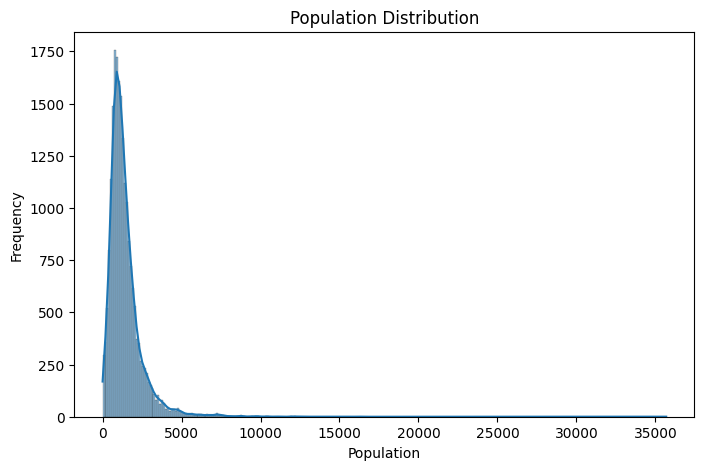

In [63]:
plt.figure(figsize=(8,5))
sns.histplot(df["population"], kde=True)
plt.title("Population Distribution")
plt.xlabel("Population")
plt.ylabel("Frequency")
plt.show()

#### 📌 Population right-skewed distribution show karta hai.

### 📦 Box Plot

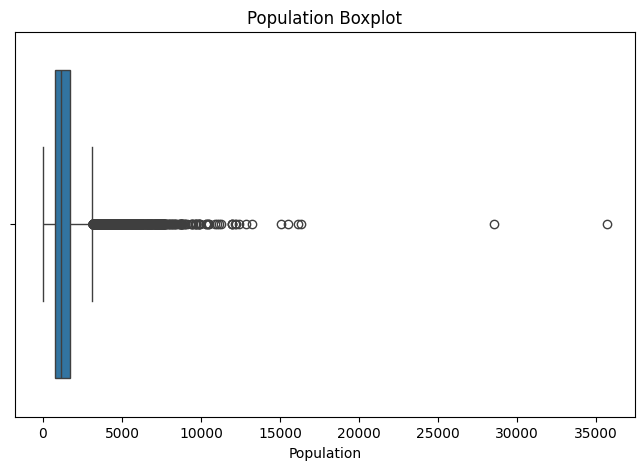

In [64]:
plt.figure(figsize=(8,5))
sns.boxplot(x=df["population"])
plt.title("Population Boxplot")
plt.xlabel("Population")
plt.show()

#### 📌 Population feature me outliers present hain.

### 📐 Skewness & Kurtosis

In [65]:
df["population"].skew()
df["population"].kurt()

np.float64(73.55311639416514)

### 🏷️ Univariate Analysis (Categorical)

### 🔢 Value Counts & Unique Values

In [66]:
df["ocean_proximity"].value_counts()
df["ocean_proximity"].nunique()

5

### 📊 Count Plot

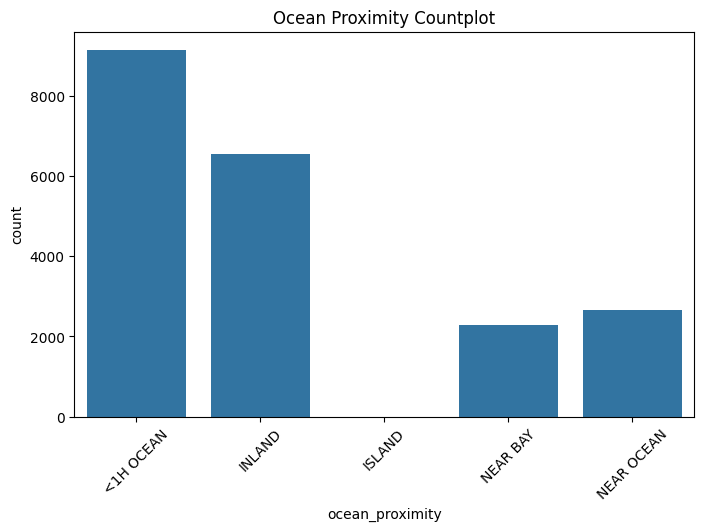

In [67]:
plt.figure(figsize=(8,5))
sns.countplot(x="ocean_proximity", data=df)
plt.title("Ocean Proximity Countplot")
plt.xticks(rotation=45)
plt.show()

#### 📌 Different ocean proximity categories ki frequency alag-alag hai.

### 🥧 Pie Chart

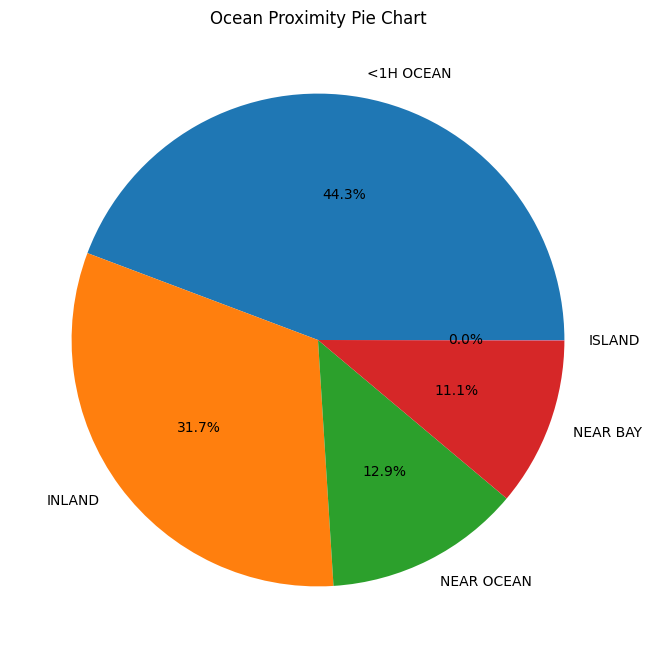

In [68]:
plt.figure(figsize=(8,8))
df["ocean_proximity"].value_counts().plot(kind="pie",autopct="%1.1f%%")
plt.title("Ocean Proximity Pie Chart")
plt.ylabel("")
plt.show()

#### 📌 Ocean proximity categories ka percentage distribution dikh raha hai.

### 🔗 Bivariate Analysis

### 🔢 vs 🔢 Numerical vs Numerical

### 📈 Correlation Check

In [69]:
df[["median_income", "median_house_value"]].corr()

,median_income,median_house_value
median_income,1.000000,0.688075
median_house_value,0.688075,1.000000


### 🎯 Scatter Plot

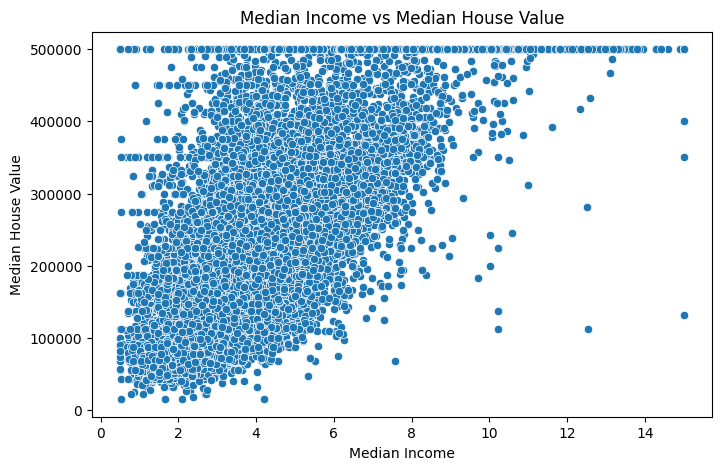

In [70]:
plt.figure(figsize=(8,5))
sns.scatterplot(x="median_income",y="median_house_value",data=df)
plt.title("Median Income vs Median House Value")
plt.xlabel("Median Income")
plt.ylabel("Median House Value")
plt.show()

#### 📌 Income aur house value ke beech positive relationship dikh raha hai.

### 📉 Regression Plot

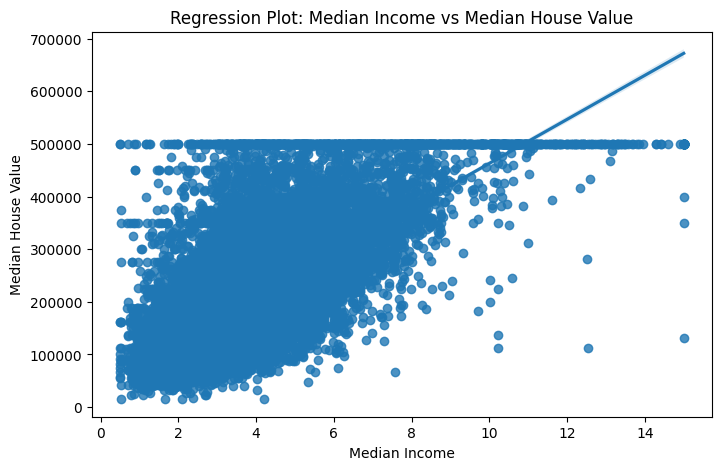

In [71]:
plt.figure(figsize=(8,5))
sns.regplot(x="median_income",y="median_house_value",data=df)
plt.title("Regression Plot: Median Income vs Median House Value")
plt.xlabel("Median Income")
plt.ylabel("Median House Value")
plt.show()

#### 📌 Income aur house value ke beech positive relationship aur trend ko regression line se show karta hai.

### 🔢 vs 🏷️ Numerical vs Categorical

### 📋 Groupby Analysis

In [72]:
df.groupby("ocean_proximity",observed=True)["median_house_value"].mean()

ocean_proximity
<1H OCEAN     240084.285464
INLAND        124805.392001
ISLAND        380440.000000
NEAR BAY      259212.311790
NEAR OCEAN    249433.977427
Name: median_house_value, dtype: float64

### 🎻 Violin Plot

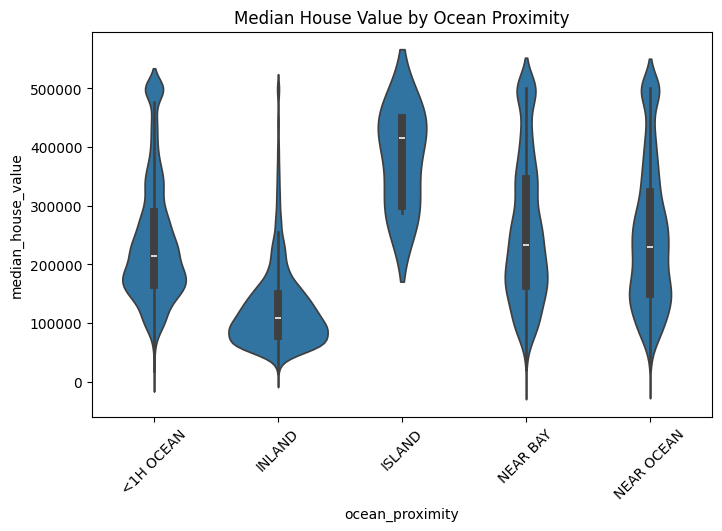

In [73]:
plt.figure(figsize=(8,5))
sns.violinplot(x="ocean_proximity",y="median_house_value",data=df)
plt.title("Median House Value by Ocean Proximity")
plt.xticks(rotation=45)
plt.show()

#### 📌 Ocean proximity ke according different areas ki house value distribution dikhata hai.

### 📊 Bar Plot

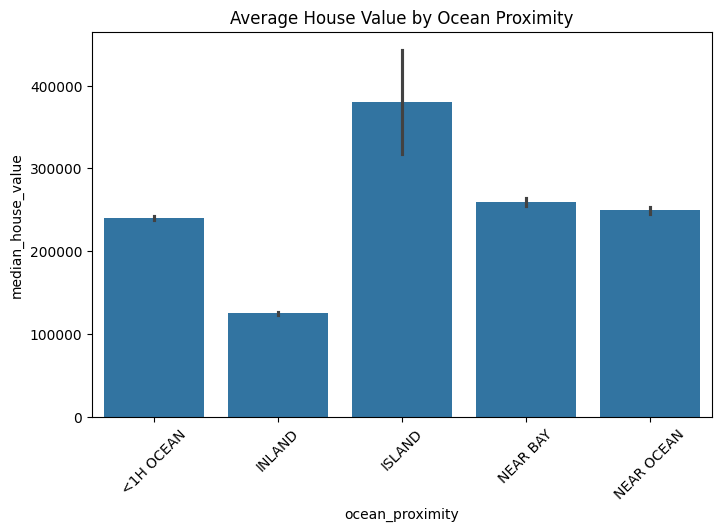

In [74]:
plt.figure(figsize=(8,5))
sns.barplot(x="ocean_proximity",y="median_house_value",data=df)
plt.title("Average House Value by Ocean Proximity")
plt.xticks(rotation=45)
plt.show()

#### 📌 Different ocean proximity areas ka average house value compare karta hai.

### 📦 Box Plot

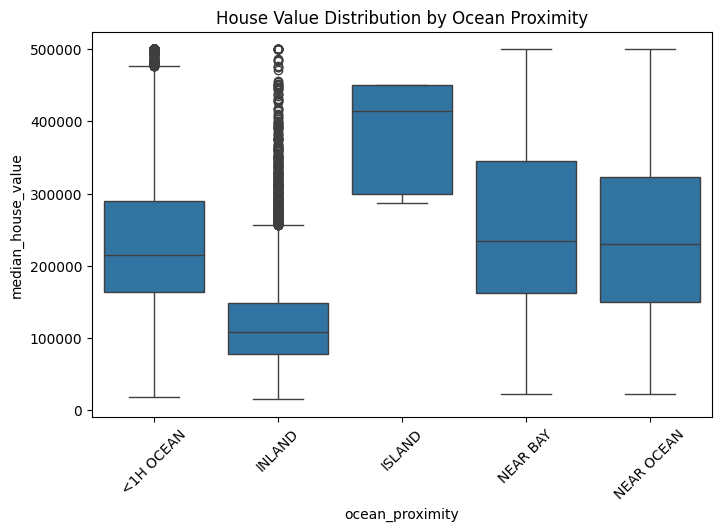

In [75]:
plt.figure(figsize=(8,5))
sns.boxplot(x="ocean_proximity",y="median_house_value",data=df)
plt.title("House Value Distribution by Ocean Proximity")
plt.xticks(rotation=45)
plt.show()

#### 📌 Box plot se data ka range, variation aur outliers samajh aate hain.

### 🏷️ vs 🏷️ Categorical vs Categorical

This dataset contains only one categorical variable, `ocean_proximity`. Therefore, Categorical vs Categorical analysis cannot be performed because at least two categorical variables are required for comparison.

### 🌟 Multivariate Analysis

### 🔥 Correlation Heatmap

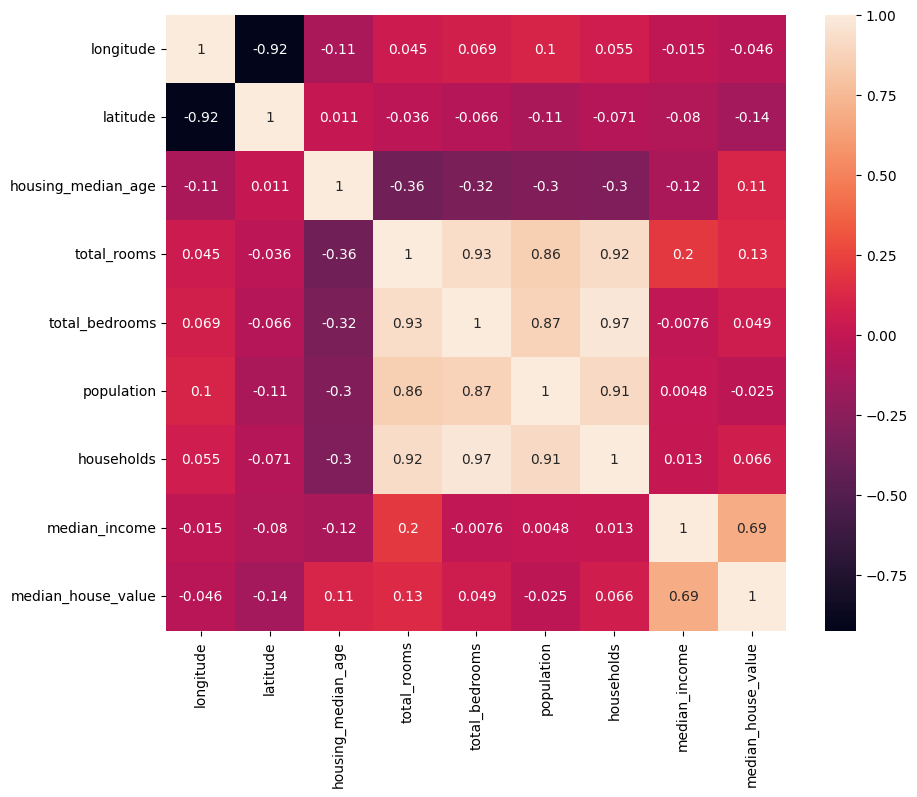

In [76]:
corr = df.corr(numeric_only=True)
plt.figure(figsize=(10,8))
sns.heatmap(corr,annot=True)
plt.show()

#### 📌 Features ke beech correlation aur relationship ko heatmap ke through show karta hai.

### 🔄 Pair Plot

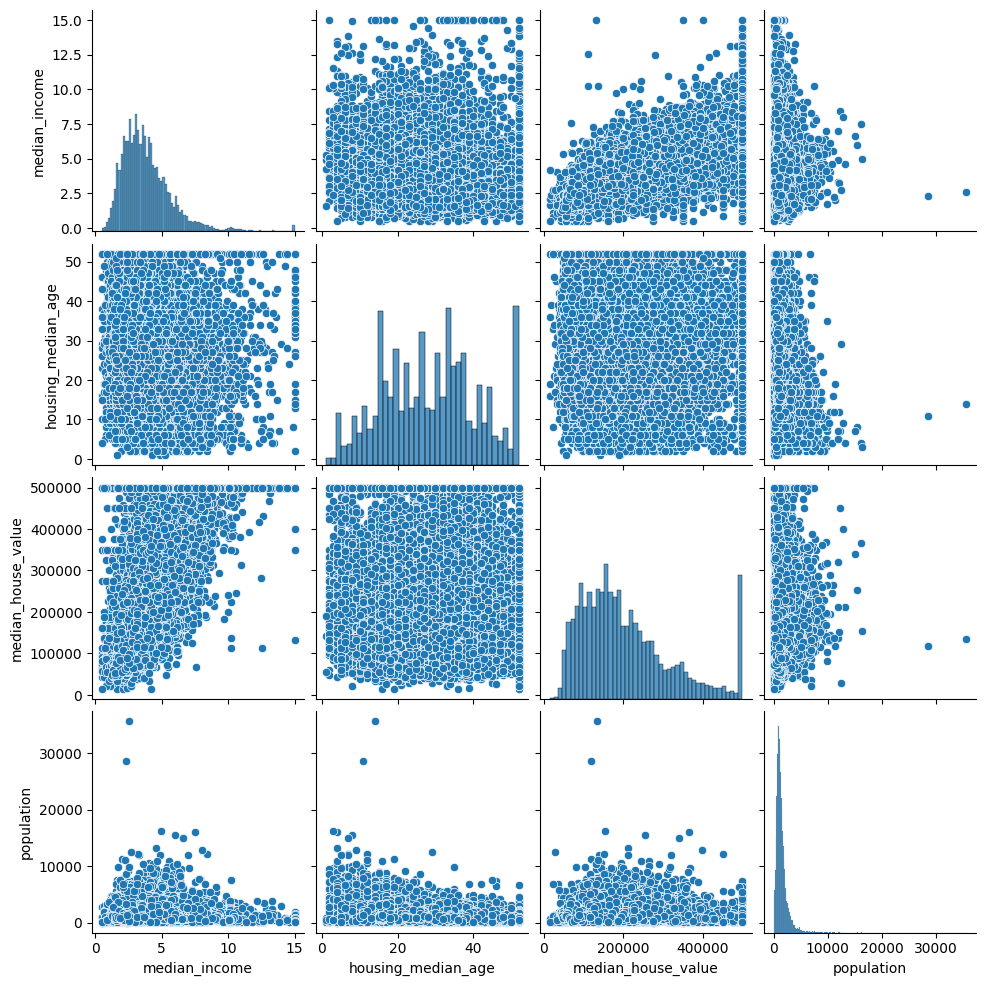

In [77]:
sns.pairplot(df[["median_income","housing_median_age","median_house_value","population"]])
plt.show()

#### 📌 Multiple numerical features ke beech relationship aur pattern ko visualize karta hai.

### 🎨 Scatter Plot with Hue and Size

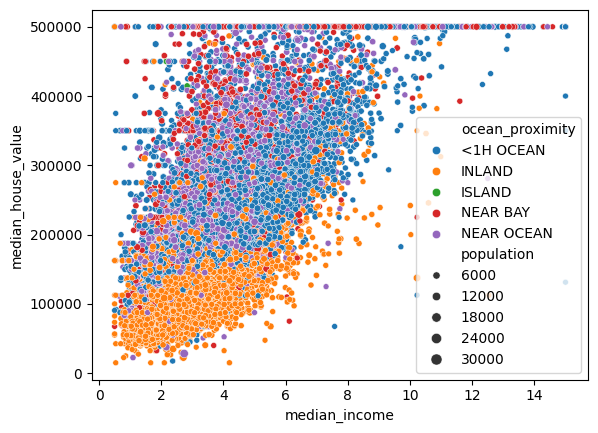

In [78]:
sns.scatterplot(x=df["median_income"],y=df["median_house_value"],hue=df["ocean_proximity"],size=df["population"])
plt.show()

#### 📌 Income aur house value ke relationship ko ocean proximity aur population size ke according show karta hai.

### 🧩 FacetGrid

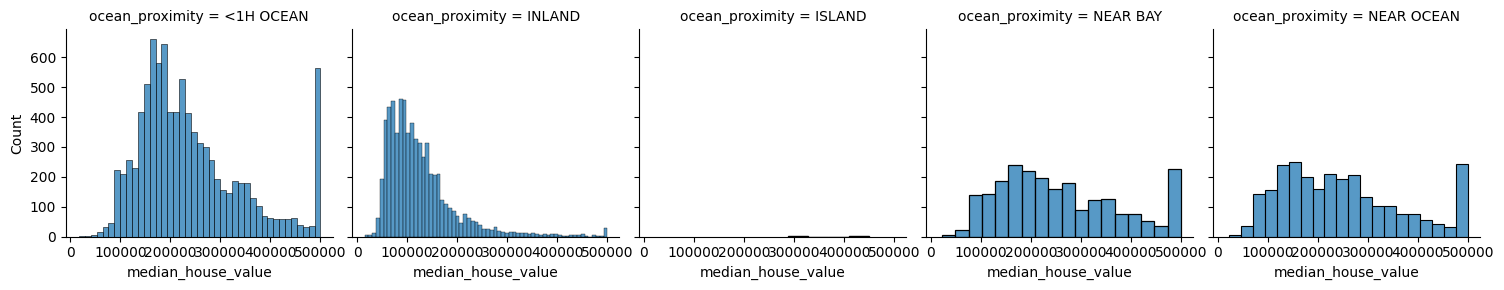

In [79]:
g = sns.FacetGrid(df,col="ocean_proximity")
g.map(sns.histplot,"median_house_value")
plt.show()

#### 📌 Different ocean proximity categories ke according house value distribution compare karta hai.

## 📋 Part E : Data Profiling

### 🚀 Generate EDA Report

In [80]:
profile = ProfileReport(
    df,
    title="House Price Prediction EDA Report",
    explorative=True      # Extra deep analysis
)

### 💾 Save Report as HTML

In [81]:
profile.to_file("House Price Prediction EDA Report.html")

Summarize dataset:   0%|          | 0/5 [00:00<?, ?it/s]

100%|██████████| 10/10 [00:00<00:00, 284.74it/s]


Generate report structure:   0%|          | 0/1 [00:00<?, ?it/s]

Render HTML:   0%|          | 0/1 [00:00<?, ?it/s]

Export report to file:   0%|          | 0/1 [00:00<?, ?it/s]

### 🖥️ Display Report in Jupyter Notebook

In [82]:
profile.to_notebook_iframe()

## 📌 Conclusion

- The dataset was collected from CSV, JSON, SQL Database, and API sources.
- Missing values were identified and handled successfully.
- Numerical and categorical features were analyzed using EDA techniques.
- The population feature contains skewness and outliers.
- Median income has a strong relationship with house prices.
- Ocean proximity affects house prices in different regions.
- Heatmaps and pair plots helped identify feature relationships.
- Data profiling provided a detailed summary of the dataset.
- The dataset is ready for Machine Learning model building.